# Time Series Risk Signals

The dataset is cross-sectional, so this is a scenario overlay rather than a proper time series forecast. It shows how average PD would move under mild and severe stress multipliers.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
trend = pd.read_csv(ROOT / "data" / "processed" / "time_series_risk_signals.csv")
trend


,statement_month,customers,average_predicted_pd,observed_default_rate,total_limit_balance,rolling_predicted_pd,baseline_pd,mild_stress_pd,severe_stress_pd
0,2025-01,237,0.141158,0.135021,21449000.0,0.141158,0.141158,0.155274,0.176448
1,2025-02,307,0.136646,0.140065,27506000.0,0.138902,0.136646,0.150310,0.170807
2,2025-03,263,0.141450,0.155894,24180000.0,0.139751,0.141450,0.155595,0.176813
3,2025-04,262,0.112977,0.133588,24523000.0,0.130358,0.112977,0.124274,0.141221
4,2025-05,255,0.139132,0.113725,22632000.0,0.131186,0.139132,0.153046,0.173916
5,2025-06,289,0.142328,0.103806,26045000.0,0.131479,0.142328,0.156561,0.177910
6,2025-07,266,0.151088,0.154135,22092000.0,0.144183,0.151088,0.166197,0.188860
7,2025-08,256,0.126229,0.128906,22548000.0,0.139882,0.126229,0.138851,0.157786
8,2025-09,254,0.130379,0.114173,21158000.0,0.135898,0.130379,0.143417,0.162974
9,2025-10,270,0.126787,0.125926,23510000.0,0.127798,0.126787,0.139466,0.158484


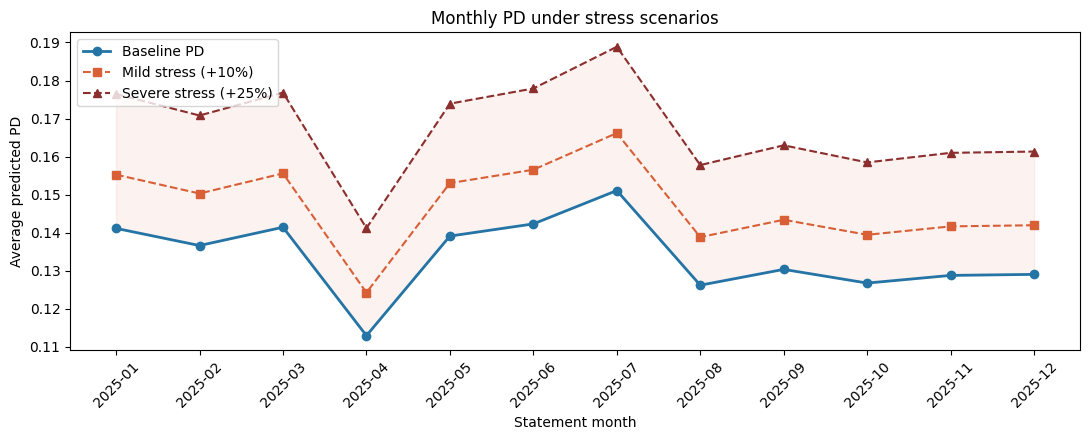

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trend["statement_month"], trend["baseline_pd"], "o-", label="Baseline PD", color="#2474a6", linewidth=2)
ax.plot(trend["statement_month"], trend["mild_stress_pd"], "s--", label="Mild stress (+10%)", color="#d95f36", linewidth=1.5)
ax.plot(trend["statement_month"], trend["severe_stress_pd"], "^--", label="Severe stress (+25%)", color="#8b2e2e", linewidth=1.5)
ax.fill_between(trend["statement_month"], trend["baseline_pd"], trend["severe_stress_pd"], alpha=0.08, color="#d95f36")
ax.set_title("Monthly PD under stress scenarios")
ax.set_ylabel("Average predicted PD")
ax.set_xlabel("Statement month")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The stress scenarios shift the entire PD curve up proportionally. In a real setting you'd want macro-linked stress models instead of flat multipliers, but this shows the basic shape of the portfolio risk signal.
